Columns in dataset:
Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')


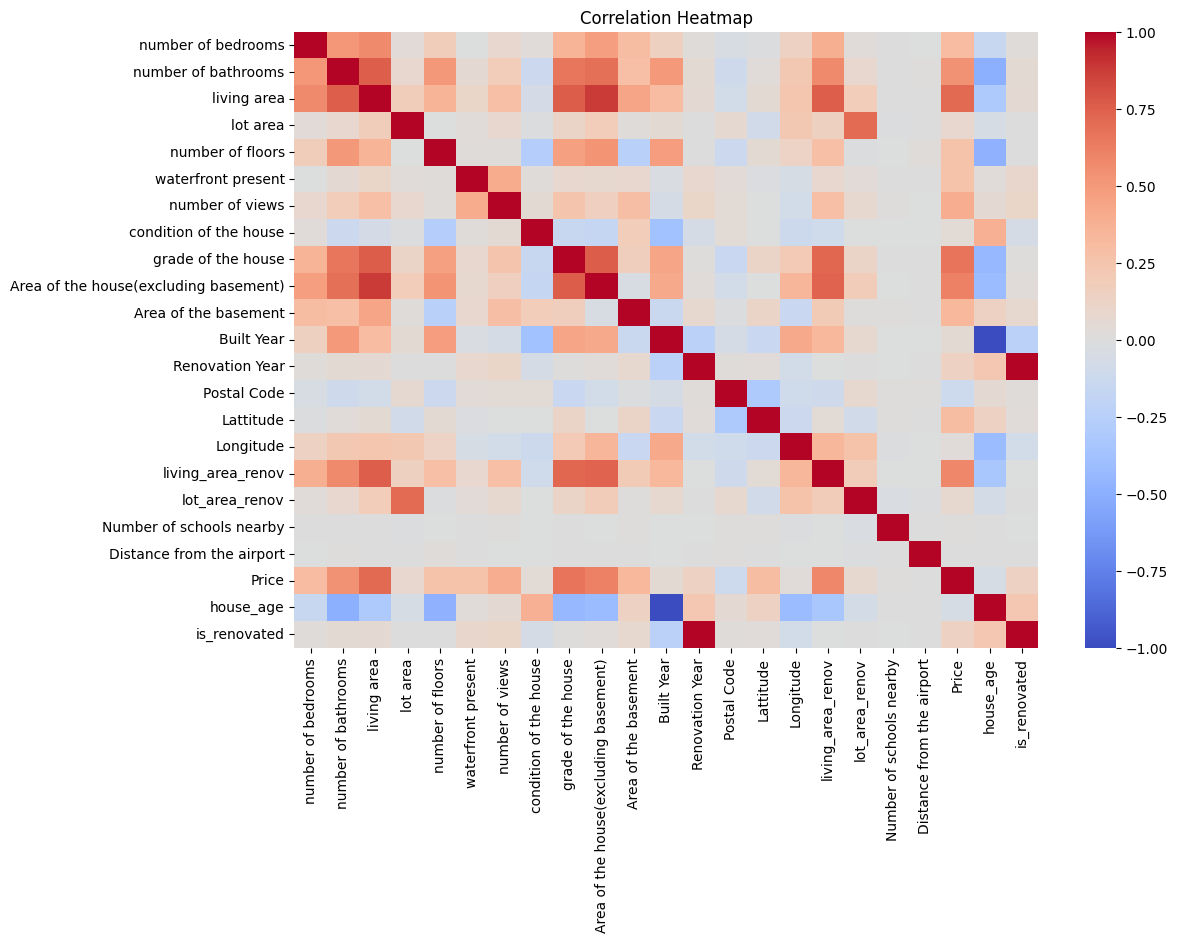

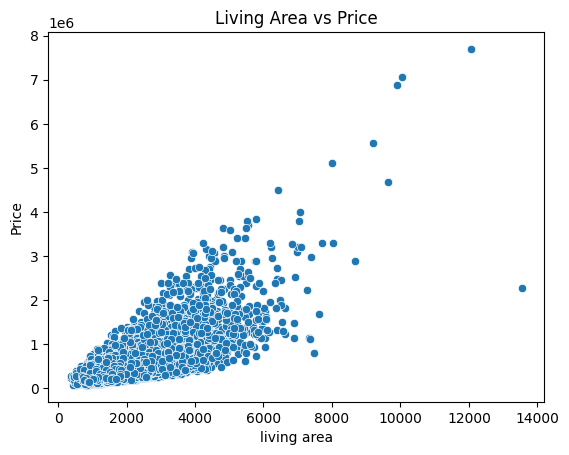


Linear Regression Performance:
MAE: 124719.80874961497
RMSE: 199058.82106768587

Decision Tree Performance:
MAE: 94392.68431582811
RMSE: 189901.7847965165


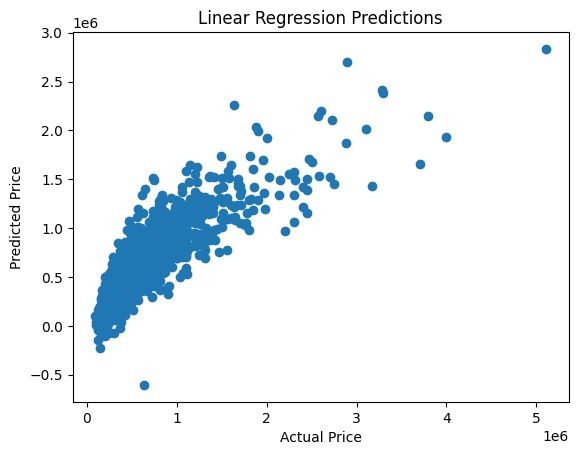

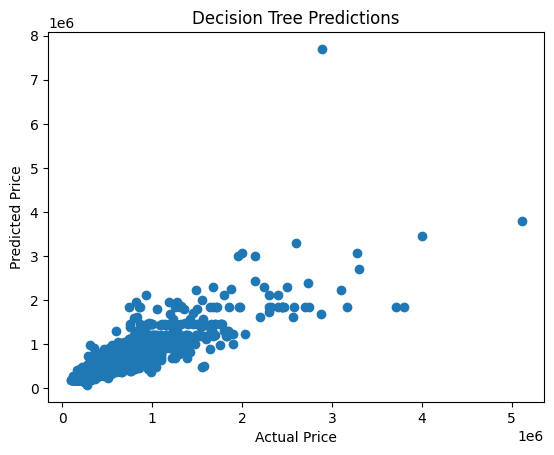

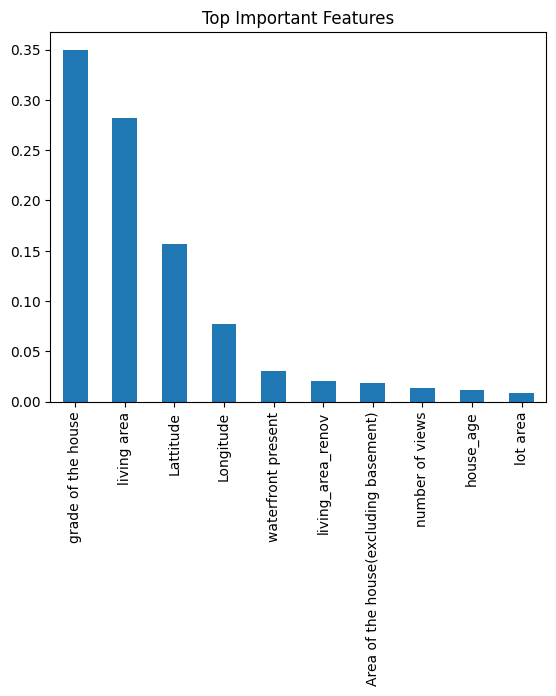


Conclusion:
Advanced models show improved prediction accuracy.
Features like living area and house grade strongly influence price.


In [4]:
# ============================================================
# ADVANCED HOUSE PRICE PREDICTION PROJECT
# ============================================================

# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ============================================================
# STEP 2: LOAD DATA
# ============================================================
df = pd.read_csv("/content/House Price India.csv")

print("Columns in dataset:")
print(df.columns)


# ============================================================
# STEP 3: DATA CLEANING
# ============================================================
# No missing values but still safe
df.fillna(df.mean(numeric_only=True), inplace=True)


# ============================================================
# STEP 4: FEATURE ENGINEERING
# ============================================================

# Drop useless columns
df.drop(['id', 'Date'], axis=1, inplace=True)

# Create new feature: House Age
df['house_age'] = 2024 - df['Built Year']

# Create renovation flag
df['is_renovated'] = df['Renovation Year'].apply(lambda x: 0 if x == 0 else 1)


# ============================================================
# STEP 5: EDA
# ============================================================

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Important relationship
plt.figure()
sns.scatterplot(x='living area', y='Price', data=df)
plt.title("Living Area vs Price")
plt.show()


# ============================================================
# STEP 6: FEATURE SELECTION
# ============================================================

X = df.drop('Price', axis=1)
y = df['Price']


# ============================================================
# STEP 7: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ============================================================
# STEP 8: MODEL 1 - LINEAR REGRESSION
# ============================================================

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)


# ============================================================
# STEP 9: MODEL 2 - DECISION TREE
# ============================================================

dt_model = DecisionTreeRegressor(max_depth=10)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)


# ============================================================
# STEP 10: EVALUATION
# ============================================================

def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Performance:")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


evaluate_model("Linear Regression", y_test, lr_pred)
evaluate_model("Decision Tree", y_test, dt_pred)


# ============================================================
# STEP 11: VISUALIZATION
# ============================================================

plt.figure()
plt.scatter(y_test, lr_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression Predictions")
plt.show()

plt.figure()
plt.scatter(y_test, dt_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree Predictions")
plt.show()


# ============================================================
# STEP 12: FEATURE IMPORTANCE
# ============================================================

importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Important Features")
plt.show()


# ============================================================
# STEP 13: CONCLUSION
# ============================================================

print("\nConclusion:")
print("Advanced models show improved prediction accuracy.")
print("Features like living area and house grade strongly influence price.")